In [1]:
!pip install -q -U google-genai langgraph networkx tree-sitter tree-sitter-python flask-ngrok pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 764.2/764.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.4/635.4 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.1/108.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 17.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.2 which is incompatible.


In [5]:
import google.genai
import langgraph
print("Setup successful!")

Setup successful!


In [23]:
from google.colab import files
files.upload()   # upload all 9 files at once

Saving state.py to state.py
Saving sample_target_report.html to sample_target_report.html
Saving sample_target.py to sample_target.py
Saving pipeline.py to pipeline.py
Saving agent4_report.py to agent4_report.py
Saving agent3_reasoner.py to agent3_reasoner.py
Saving agent1_parser.py to agent1_parser.py
Saving agent1_5_branch.py to agent1_5_branch.py


{'state.py': b'"""\nstate.py \xe2\x80\x94 Shared AgentState\nThis is the "memory" of the agentic pipeline.\nEvery agent reads from and writes to this object.\nLangGraph passes it between nodes automatically.\n"""\n\nfrom typing import TypedDict, Optional\nfrom dataclasses import dataclass, field\n\n\n# \xe2\x94\x80\xe2\x94\x80 Per-variable data structures \xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\xe2\x94\x80\n\n@dataclass\nclass Assignment:\n    name: str\n    line: int\n    value_text: str\n\n\n@dataclass\nclass OutputNode:\n    kind: str    

In [24]:
from google import genai
import os

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

print("Models supporting generateContent:")
for m in client.models.list():
    if "generateContent" in m.supported_actions:
        print(f" - {m.name}") # Use these exact strings in your code

Models supporting generateContent:
 - models/gemini-2.5-flash
 - models/gemini-2.5-pro
 - models/gemini-2.0-flash
 - models/gemini-2.0-flash-001
 - models/gemini-2.0-flash-lite-001
 - models/gemini-2.0-flash-lite
 - models/gemini-2.5-flash-preview-tts
 - models/gemini-2.5-pro-preview-tts
 - models/gemma-3-1b-it
 - models/gemma-3-4b-it
 - models/gemma-3-12b-it
 - models/gemma-3-27b-it
 - models/gemma-3n-e4b-it
 - models/gemma-3n-e2b-it
 - models/gemma-4-26b-a4b-it
 - models/gemma-4-31b-it
 - models/gemini-flash-latest
 - models/gemini-flash-lite-latest
 - models/gemini-pro-latest
 - models/gemini-2.5-flash-lite
 - models/gemini-2.5-flash-image
 - models/gemini-3-pro-preview
 - models/gemini-3-flash-preview
 - models/gemini-3.1-pro-preview
 - models/gemini-3.1-pro-preview-customtools
 - models/gemini-3.1-flash-lite-preview
 - models/gemini-3-pro-image-preview
 - models/nano-banana-pro-preview
 - models/gemini-3.1-flash-image-preview
 - models/lyria-3-clip-preview
 - models/lyria-3-pro-pr

In [34]:
import os
from google.colab import userdata

# Recommendation: Store your key in Colab "Secrets" (🔑 icon) as 'GEMINI_API_KEY'
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

!python pipeline.py sample_target.py


 Dead Logic Detector v3 — LangGraph Pipeline
[Agent 1] Parsing: sample_target.py
[Agent 1] 11 assignments, 5 outputs, 1 nested condition groups, 5 functions
[Agent 1.5] Checking 1 nested condition groups...
  [Agent 1.5] IMPOSSIBLE (heuristic) line 27: age < 18
  [Agent 1.5] Explanation generated by LLM for line 27
[Agent 1.5] Found 1 impossible branches
[Agent 2] Building data flow graph...
[Agent 2] 2 live, 6 dead variables found
[Agent 2] 3 shadowed assignments found
  [Agent 2] LLM explanation for shadowed 'base_discount' at line 7
  [Agent 2] LLM explanation for shadowed 'base_discount' at line 10
  [Agent 2] LLM explanation for shadowed 'status' at line 25
[Agent 3] Sending batch of 6 variables to Gemini...
[Agent 3] replied with: {
  "results": [
    {
      "variable": "display_...
[Agent 4] Generating HTML report...
[Agent 4] Report saved → sample_target_report.html

 Done. Report → sample_target_report.html



In [35]:
from IPython.display import HTML

# Replace 'sample_target_report.html' with your actual report filename
report_path = 'sample_target_report.html'

with open(report_path, 'r') as f:
    html_content = f.read()

display(HTML(html_content))

Line,Variable,Severity,Explanation,Suggestion
20,display_name,🔴 HIGH,"The variable 'display_name' is assigned a formatted string on line 20 but is never subsequently accessed or used within the function, nor is it part of the return value or any side-effecting operation. It constitutes entirely unused computation.",This variable and its assignment can be safely removed without impacting the program's logic or behavior.
36,internal_api_version,🟡 MEDIUM,"The variable 'internal_api_version' is assigned a string literal on line 36. Although it might have served a purpose during debugging or development, it is never read or utilized elsewhere in the code path, indicating it is currently dead logic.","Review if this variable was part of an unfinished feature or debugging effort. If not, it can be safely removed."
37,trace_id,🟡 MEDIUM,"The variable 'trace_id' is assigned a hexadecimal string on line 37. As with similar debug scaffolds, it appears to be a leftover from development or debugging. It is not read or used in any subsequent operations.","Confirm if 'trace_id' is intended for future use or if it's an obsolete debug artifact. If obsolete, remove it."
45,a,🔴 HIGH,"The variable 'a' is initialized on line 45 and used solely to compute 'b', which then computes 'c'. The final variable 'c' is never utilized, making the entire chain of 'a', 'b', and 'c' dead. This computation serves no purpose.","The entire calculation chain involving 'a', 'b', and 'c' is unused and can be safely removed."
46,b,🔴 HIGH,"The variable 'b' is computed from 'a' on line 46 and subsequently used only to calculate 'c'. Since 'c' itself is a dead variable and never read, the computation of 'b' ultimately leads to no observable effect or return value.","As part of a larger dead computation chain, 'b' and its assignment can be safely removed along with 'a' and 'c'."
47,c,🔴 HIGH,"The variable 'c' is assigned the result of a calculation on line 47. However, 'c' is never read or utilized by any subsequent expression, return statement, or side-effecting operation, rendering its computation entirely superfluous and dead.","This variable and its assignment are dead code and can be safely deleted, along with the preceding calculations that lead to it."
Line,Variable,First value,Issue,Fix
7,base_discount,price * 0.05,"The variable `base_discount` is initially assigned `price * 0.05` on line 7. This value is immediately overwritten by `price * 0.20` on line 10 if `member_level` is 'GOLD' before `base_discount` is ever read, making the first assignment completely redundant with zero effect on program behavior.",Remove the unnecessary assignment `base_discount = price * 0.05` on line 7. Consider initializing `base_discount` directly within the `else` block if `price * 0.05` is the intended discount for non-GOLD members.
10,base_discount,price * 0.20,"The variable `base_discount` is first assigned the value `price * 0.20` at line 10. According to the problem description, this initial assignment is immediately overwritten by `base_discount = price * 0.10` at line 12 before `base_discount` is read or used, rendering the first assignment completely ineffective.","Remove the redundant assignment `base_discount = price * 0.20` at line 10, as its value is never utilized. This cleans up dead code and improves readability. If `price * 0.20` was intended to be used under specific conditions, the logic needs to be restructured to prevent its unconditional overwrite."
25,status,"""active""","The variable 'status' is first assigned the value ""active"" on line 25. If the logically impossible condition (`age > 65` AND `age < 18`) were simultaneously met, this value would be immediately overwritten by ""out_of_range_error"" on line 28 without any intermediate read. Thus, the initial assignment on line 25 would have zero effect on the program's behavior if that specific (unreachable) path were executed.","The primary issue is the contradictory `if age > 65: if age < 18:` condition, whic

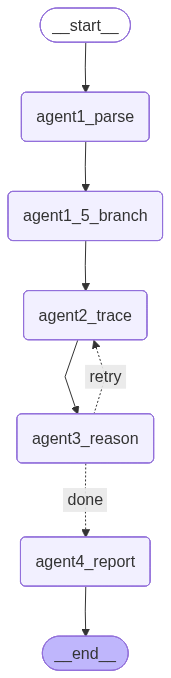

In [15]:
from IPython.display import Image, display
from pipeline import build_pipeline

app = build_pipeline().compile()

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_ascii())